In [1]:
# The goal is to make some code that will extract the frames / trajectories from each "state" 
# And basically out put the PDBs 
# And also jsut give a list of those frames basically.

In [2]:
import MDAnalysis as mda
from numpy import *
import os
from pylab import *
import MDAnalysis.analysis.distances
import MDAnalysis.analysis.rms
from MDAnalysis.analysis import align
import glob
import umap
import scipy.stats
import sklearn
import sklearn.decomposition
import sklearn.preprocessing
import pandas as pd
import mdtraj
import seaborn as sns
from MDAnalysis.analysis.hydrogenbonds.hbond_analysis import HydrogenBondAnalysis as HBA

In [3]:
import os

########################################################
#############      FOR NOW EQPOINT IS 0   ##############
########################################################
EQPOINT=0

systemFolders = glob.glob("huNumbering/*t5a*/")

systemgros=[]
systemtprs=[]
systemtrjs=[]
for i in range(len(systemFolders)):
    systemgros.append(sorted(glob.glob(systemFolders[i]+"*.gro")))
    systemtprs.append(sorted(glob.glob(systemFolders[i]+"*.tpr")))
    systemtrjs.append(sorted(glob.glob(systemFolders[i]+"*.xtc")))


    
    
threeColor=["#FE6100","#332288","#882255"]
colourScheme= threeColor
system_names = ["rhT5A","T5A","T5AR332P"]
systems=[]
for i in range(len(systemgros)):
    sub=[]
    for j in range(len(systemgros[i])):
        # When using TPRs, residues are indexed from 1; so we need to add in the first residue, 1 - 1 + first resid=first resid
        #firstres = mda.Universe(systemgros[i][j]).residues.resids[0]-1
        tu = mda.Universe(systemgros[i][j],systemtrjs[i][j])
        #tu.residues.resids +=firstres
                          
        sub.append(tu)
        
    systems.append(sub)


bodys=[]
bodystrings=[]
# rhesus v1 is 326-349
# Human v1 is 324-345
#huloopstring = "resid 324:345"
#rhloopstring = "resid 326:349"
combinedLoopString="resid 324:345"
#system_loop_strings = [rhloopstring,huloopstring,huloopstring]
for i in range(len(systems)):
    sub = []
    sub2 = []
    for j in range(len(systems[i])):
        sub.append(systems[i][j].select_atoms("protein and not ("+combinedLoopString+")"))
        sub2.append("protein and not ("+combinedLoopString+")")
        
    bodys.append(sub)
    bodystrings.append(sub2)
    
    
v1s=[]
v1strings=[]
# rhesus v1 is 326-349
# Human v1 is 324-345
#huloopstring = "resid 324:345"
#rhloopstring = "resid 326:349"
combinedLoopString="resid 324:345"
#system_loop_strings = [rhloopstring,huloopstring,huloopstring]
for i in range(len(systems)):
    sub = []
    sub2 = []

    for j in range(len(systems[i])):
        sub.append(systems[i][j].select_atoms("protein and "+combinedLoopString))
        sub2.append("protein and "+combinedLoopString)

        
    v1s.append(sub)        
    v1strings.append(sub2)
                   
        
v2s=[]
v2strings=[]
# rhesus v1 is 326-349
# Human v1 is 324-345
#huloopstring = "resid 324:345"
#rhloopstring = "resid 326:349"
combinedLoopString="resid 380:400"
#system_loop_strings = [rhloopstring,huloopstring,huloopstring]
for i in range(len(systems)):
    sub = []
    sub2 = []

    for j in range(len(systems[i])):
        sub.append(systems[i][j].select_atoms("protein and "+combinedLoopString))
        sub2.append("protein and "+combinedLoopString)

        
    v2s.append(sub)        
    v2strings.append(sub2)
    
    
    
v3s=[]
v3strings=[]
combinedLoopString="resid 415:430"
#system_loop_strings = [rhloopstring,huloopstring,huloopstring]
for i in range(len(systems)):
    sub = []
    sub2 = []

    for j in range(len(systems[i])):
        sub.append(systems[i][j].select_atoms("protein and "+combinedLoopString))
        sub2.append("protein and "+combinedLoopString)

        
    v3s.append(sub)        
    v3strings.append(sub2)

C:\Users\Liam\anaconda3\lib\site-packages\MDAnalysis\topology\base.py:203: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  residx = np.zeros_like(criteria[0], dtype=np.int)
C:\Users\Liam\anaconda3\lib\site-packages\MDAnalysis\core\selection.py:640: DeprecationWarning: `np.bool` is a deprecated alias for the builtin `bool`. To silence this warning, use `bool` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.bool_` here.
Deprecated in NumPy 1.20; for more details and guidance: h

In [4]:
# Let's just make a test state list


states = array([[0,1,1,2,-1,-1,0,1],
                [3,1,-1,3,4,2,0,1]],
               )

In [5]:
def get_system_state_indices(states):


    unique_states = array(list(sorted(set(states.flatten()))))

    # What we want: for each state, we want a list of all indices [trj,frame] in each state.

    alltrjs=[]
    allframes=[]
    for st_i in range(len(unique_states)):
        st = unique_states[st_i]
        rows,cols = where(states == st)
        alltrjs.append(rows)
        allframes.append(cols)


    allindices = [alltrjs,allframes]
    
    return allindices

allindices = get_system_state_indices(states)

C:\Users\Liam\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(
C:\Users\Liam\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


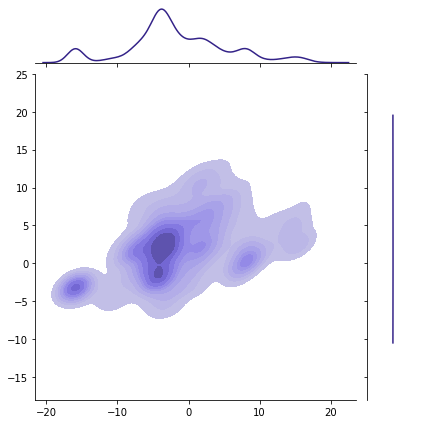

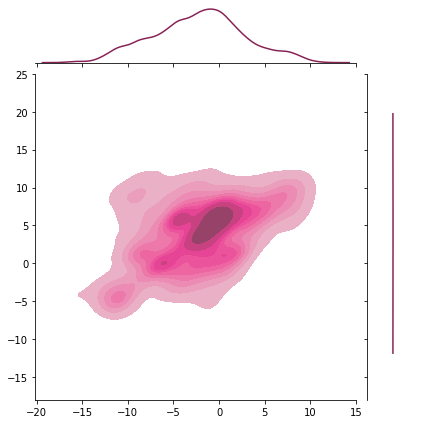

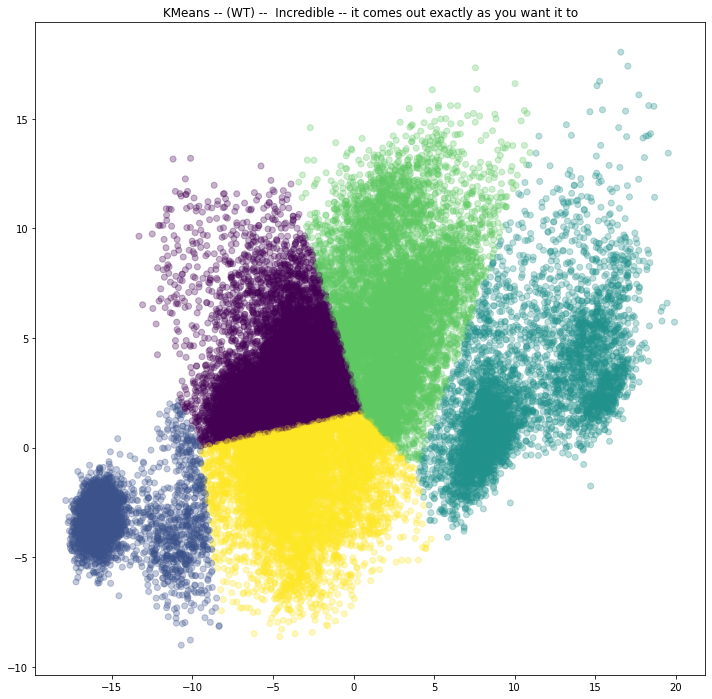

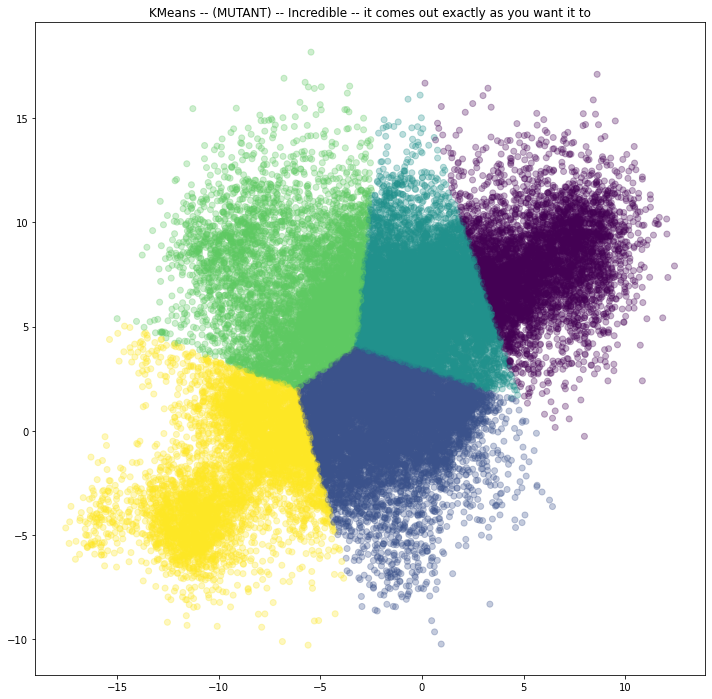

In [6]:
# Ok let's do PCA
def getPairwiseDists(systems,datasets,selection_strings,stride = 10,EQPOINT=250):
    
    alldists=[]
    for i in range(len(datasets)):
        subdists=[]
        for j in range(len(datasets[i])):
            distances=[]
            for k in range(int(EQPOINT/stride),int(len(systems[i][j].trajectory)/stride)):
                systems[i][j].trajectory[k*stride]
                distances.append(MDAnalysis.analysis.distances.self_distance_array(datasets[i][j].select_atoms("name CA").positions))
            subdists.append(distances)
        alldists.append(subdists)
    return alldists



v2dists = getPairwiseDists(systems,v2s,v2strings,stride = 1,EQPOINT=EQPOINT)

v2shaped_dists=[]
v2pca_colours = []
for i in range(len(v2dists)):
    for j in range(len(v2dists[i])):
        for k in range(len(v2dists[i][j])):
            v2shaped_dists.append(v2dists[i][j][k])
            v2pca_colours.append(colourScheme[i])
            
            

v2Z=sklearn.preprocessing.StandardScaler().fit_transform(v2shaped_dists)

v2myPCA=sklearn.decomposition.PCA(n_components=2)
v2myfit=v2myPCA.fit(v2Z)
v2pcaX=v2myPCA.transform(v2Z)
v2pcaPoints= v2pcaX.T


#Create a scaler
v2scaler = sklearn.preprocessing.StandardScaler()
# Fit scaler with the distances from the structures
v2scaler.fit(v2shaped_dists)
# get the mean and scale of this transformation
v2scale_final = v2scaler.scale_
v2mean_final = v2scaler.mean_


v2scaled_dists = (copy(v2dists) - v2mean_final)/v2scale_final
v2transformed_dists = []
for i in range(len(v2scaled_dists)):
    sub=[]
    for j in range(len(v2scaled_dists[i])):
        sub.append(v2myPCA.transform(v2scaled_dists[i][j]))
        
    v2transformed_dists.append(sub)
    
    
sns.jointplot(v2pcaPoints[0][int(len(v2pcaPoints[0])/3):2*int(len(v2pcaPoints[0])/3)],v2pcaPoints[1][int(len(v2pcaPoints[0])/3):2*int(len(v2pcaPoints[0])/3)],kind = 'kde',shade= True, color = colourScheme[1])

#xticks([])
#yticks([])
ylim(-18,25)
xlim(-18,21)
xlabel("PC1",fontsize = 30)
ylabel("PC2",fontsize = 30)


sns.jointplot(v2pcaPoints[0][2*int(len(v2pcaPoints[0])/3):],v2pcaPoints[1][2*int(len(v2pcaPoints[0])/3):],kind = 'kde',shade = True,color=colourScheme[2])
#xticks([])
#yticks([])
ylim(-18,25)
xlim(-18,21)
xlabel("PC1",fontsize = 30)


show()



from sklearn.cluster import KMeans

v2km_w = KMeans(n_clusters = 5)
v2km_w.fit(array(v2transformed_dists[1]).reshape(-1,2))


figure(figsize = (12,12))
scatter(array(v2transformed_dists[1]).reshape(-1,2)[:,0],array(v2transformed_dists[1]).reshape(-1,2)[:,1],c = v2km_w.labels_,alpha = 0.3)
title("KMeans -- (WT) --  Incredible -- it comes out exactly as you want it to")

show()

from sklearn.cluster import KMeans

v2km_m = KMeans(n_clusters = 5)
v2km_m.fit(array(v2transformed_dists[2]).reshape(-1,2))


figure(figsize = (12,12))
scatter(array(v2transformed_dists[2]).reshape(-1,2)[:,0],array(v2transformed_dists[2]).reshape(-1,2)[:,1],c = v2km_m.labels_,alpha = 0.3)
title("KMeans -- (MUTANT) -- Incredible -- it comes out exactly as you want it to")
show()

C:\Users\Liam\anaconda3\lib\site-packages\MDAnalysis\core\selection.py:521: DeprecationWarning: `np.bool` is a deprecated alias for the builtin `bool`. To silence this warning, use `bool` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.bool_` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  mask = np.zeros(len(group), dtype=np.bool)
C:\Users\Liam\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(
C:\Users\Liam\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argu

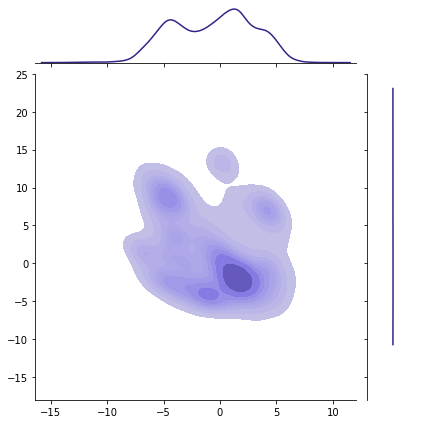

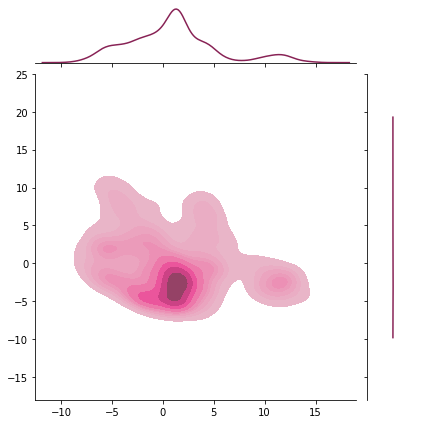

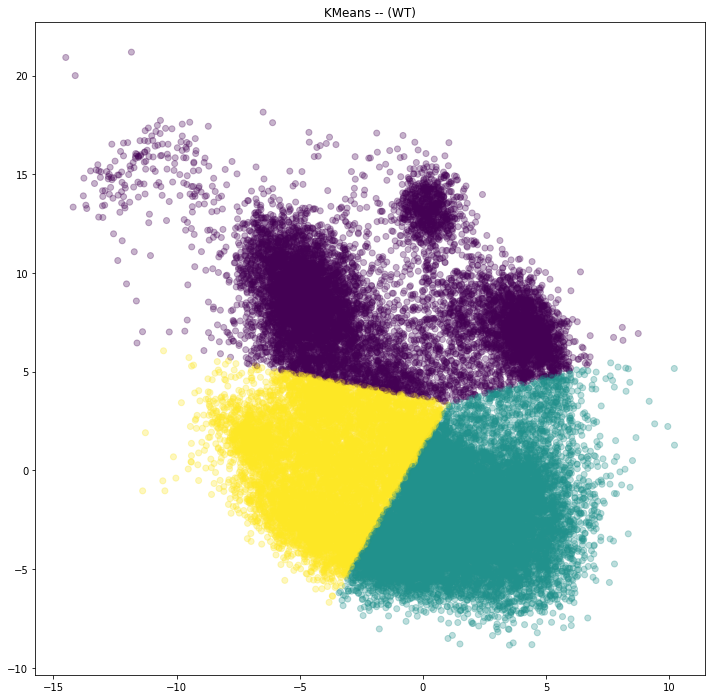

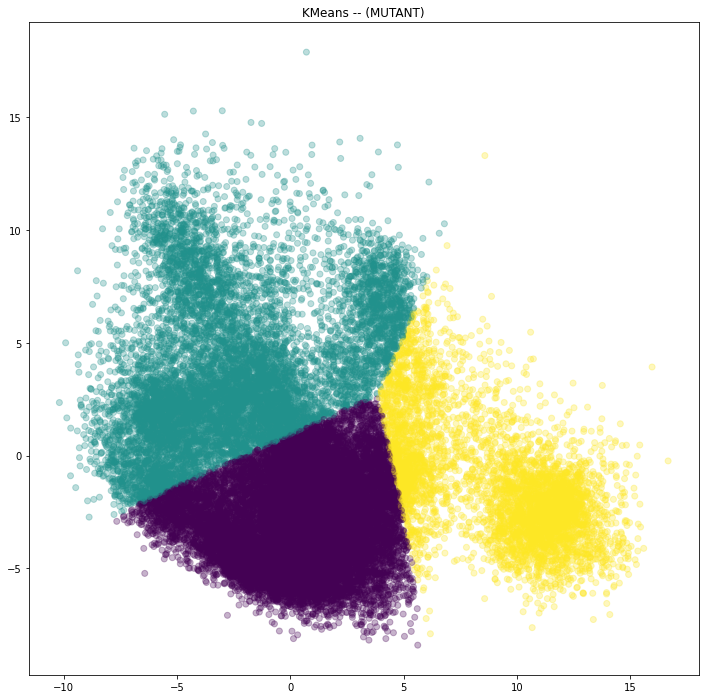

In [7]:
# Ok let's do PCA
def getPairwiseDists(systems,datasets,selection_strings,stride = 10,EQPOINT=250):
    
    alldists=[]
    for i in range(len(datasets)):
        subdists=[]
        for j in range(len(datasets[i])):
            distances=[]
            for k in range(int(EQPOINT/stride),int(len(systems[i][j].trajectory)/stride)):
                systems[i][j].trajectory[k*stride]
                distances.append(MDAnalysis.analysis.distances.self_distance_array(datasets[i][j].select_atoms("name CA").positions))
            subdists.append(distances)
        alldists.append(subdists)
    return alldists



v3dists = getPairwiseDists(systems,v3s,v3strings,stride = 1,EQPOINT=EQPOINT)

v3shaped_dists=[]
v3pca_colours = []
for i in range(len(v3dists)):
    for j in range(len(v3dists[i])):
        for k in range(len(v3dists[i][j])):
            v3shaped_dists.append(v3dists[i][j][k])
            v3pca_colours.append(colourScheme[i])
            
            

v3Z=sklearn.preprocessing.StandardScaler().fit_transform(v3shaped_dists)

v3myPCA=sklearn.decomposition.PCA(n_components=2)
v3myfit=v3myPCA.fit(v3Z)
v3pcaX=v3myPCA.transform(v3Z)
v3pcaPoints= v3pcaX.T


#Create a scaler
v3scaler = sklearn.preprocessing.StandardScaler()
# Fit scaler with the distances from the structures
v3scaler.fit(v3shaped_dists)
# get the mean and scale of this transformation
v3scale_final = v3scaler.scale_
v3mean_final = v3scaler.mean_


v3scaled_dists = (copy(v3dists) - v3mean_final)/v3scale_final
v3transformed_dists = []
for i in range(len(v3scaled_dists)):
    sub=[]
    for j in range(len(v3scaled_dists[i])):
        sub.append(v3myPCA.transform(v3scaled_dists[i][j]))
        
    v3transformed_dists.append(sub)
    
    
sns.jointplot(v3pcaPoints[0][int(len(v3pcaPoints[0])/3):2*int(len(v3pcaPoints[0])/3)],v3pcaPoints[1][int(len(v3pcaPoints[0])/3):2*int(len(v3pcaPoints[0])/3)],kind = 'kde',shade= True, color = colourScheme[1])

#xticks([])
#yticks([])
ylim(-18,25)
xlim(-18,21)
xlabel("PC1",fontsize = 30)
ylabel("PC2",fontsize = 30)


sns.jointplot(v3pcaPoints[0][2*int(len(v3pcaPoints[0])/3):],v3pcaPoints[1][2*int(len(v3pcaPoints[0])/3):],kind = 'kde',shade = True,color=colourScheme[2])
#xticks([])
#yticks([])
ylim(-18,25)
xlim(-18,21)
xlabel("PC1",fontsize = 30)


show()



from sklearn.cluster import KMeans

v3km_w = KMeans(n_clusters = 3)
v3km_w.fit(array(v3transformed_dists[1]).reshape(-1,2))


figure(figsize = (12,12))
scatter(array(v3transformed_dists[1]).reshape(-1,2)[:,0],array(v3transformed_dists[1]).reshape(-1,2)[:,1],c = v3km_w.labels_,alpha = 0.3)
title("KMeans -- (WT)")
show()

from sklearn.cluster import KMeans

v3km_m = KMeans(n_clusters = 3)
v3km_m.fit(array(v3transformed_dists[2]).reshape(-1,2))


figure(figsize = (12,12))
scatter(array(v3transformed_dists[2]).reshape(-1,2)[:,0],array(v3transformed_dists[2]).reshape(-1,2)[:,1],c = v3km_m.labels_,alpha = 0.3)
title("KMeans -- (MUTANT)")
show()

C:\Users\Liam\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


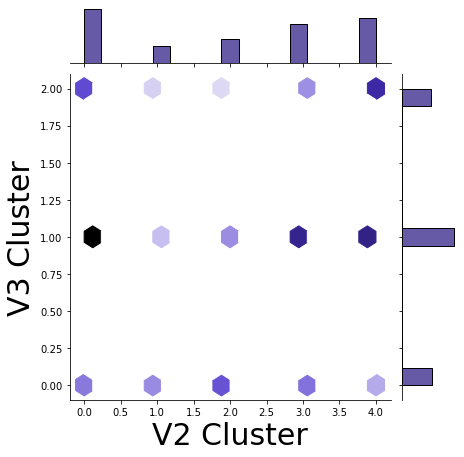

In [8]:
h = sns.jointplot(v2km_w.labels_,v3km_w.labels_,color = colourScheme[1],kind = 'hex')
h.set_axis_labels('V2 Cluster','V3 Cluster',fontsize = 30)



C:\Users\Liam\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


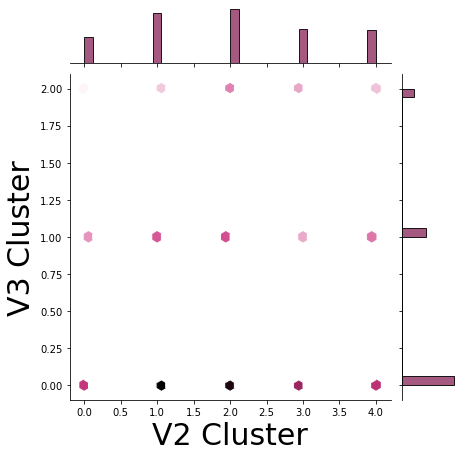

In [9]:
h = sns.jointplot(v2km_m.labels_,v3km_m.labels_,color = colourScheme[2],kind = 'hex')
h.set_axis_labels('V2 Cluster','V3 Cluster',fontsize = 30)
#h.ax_joint.set_xticks(fontsize = 30)

In [ ]:
state_0_2_wt_frames = where((v1km_w.labels_ == 0) & (v2km_w.labels_ == 2))[0]
other_states_frames = where(((v1km_w.labels_ != 0) & (v2km_w.labels_ != 2)))[0]

In [70]:

allcontacts_ts=[]

for i in range(len(system_names)):
    allcontacts_ts.append(load("allcontacts_ts_"+system_names[i]+".npy"))

In [71]:
state_0_2_wt_frames_contacts=allcontacts_ts[1].T.reshape(20100,-1)[:,state_0_2_wt_frames]
avg_state_0_2_wt_frames_contacts = mean(state_0_2_wt_frames_contacts,axis = 1)


other_states_frames_contacts=allcontacts_ts[1].T.reshape(20100,-1)[:,other_states_frames]
avg_other_states_frames_contacts = mean(other_states_frames_contacts,axis = 1)



In [72]:
def BestTwoD(array1d):
    #The number of dimensions (excluding nearest neighbours and self)
    N = int(1.5 + .5*np.sqrt(1+(8*len(array1d))))

    #Construct a 2D version of the contact map (it excludes nearesty neighbours and self, but there are still NxN slots)
    twoD=zeros((N,N))            
    j=2
    k=0
    for i in range(len(array1d)):
        if abs(j-k)>1:
            twoD[j][k] = array1d[i]
            twoD[k][j] = array1d[i]
        j+=1
        if j == len(twoD):
            k+=1
            j = k+2
            if k==len(twoD)-2 and j >len(twoD)-2 :
                break
    return twoD

twod_avg_state_0_2_wt_frames_contacts= BestTwoD(avg_state_0_2_wt_frames_contacts)
twod_avg_other_states_frames_contacts= BestTwoD(avg_other_states_frames_contacts)

(34.0, 60.0)

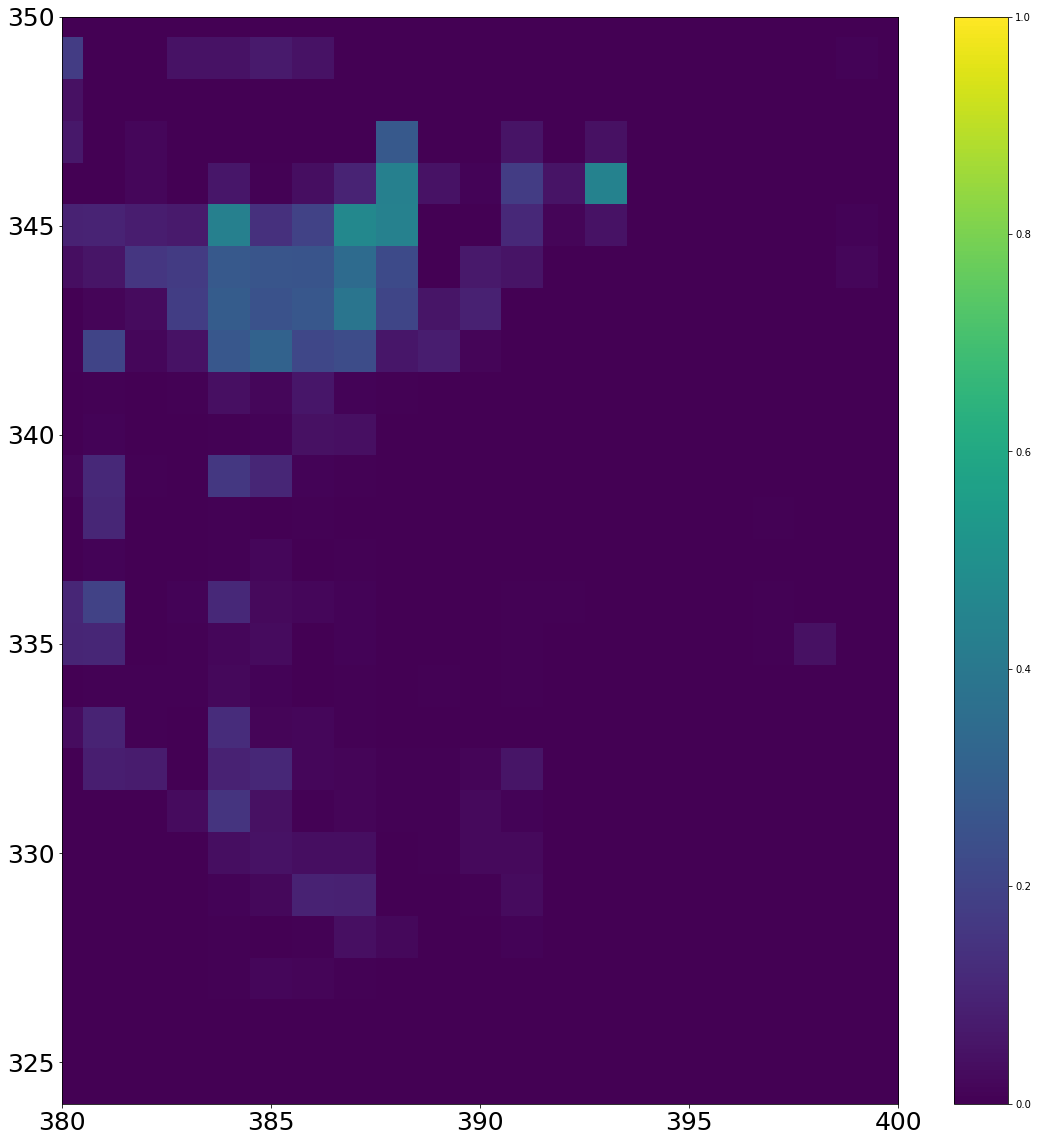

In [73]:
huresids = systems[1][0].select_atoms("protein").residues.resids
figure(figsize = (20,20))
imshow(twod_avg_state_0_2_wt_frames_contacts,origin = "lower")
_=xticks(arange(len(huresids))[::5],huresids[::5],fontsize = 25)
_=yticks(arange(len(huresids))[::5],huresids[::5],fontsize = 25)

colorbar()

xlim(380-290,400-290)
ylim(324-290,350-290)

(34.0, 60.0)

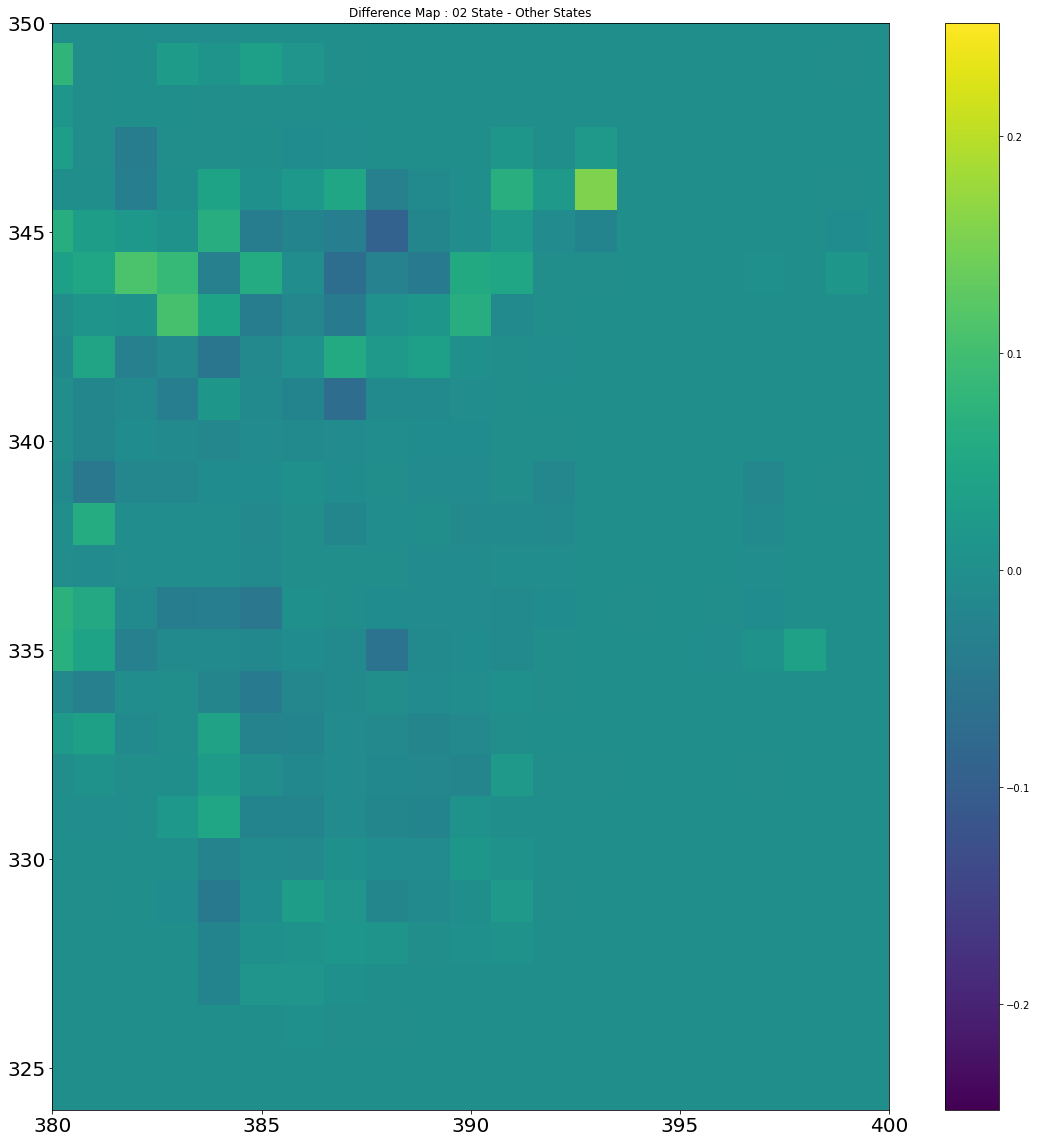

In [75]:
huresids = systems[1][0].select_atoms("protein").residues.resids
figure(figsize = (20,20))
imshow(twod_avg_state_0_2_wt_frames_contacts - twod_avg_other_states_frames_contacts,origin = "lower")
_=xticks(arange(len(huresids))[::5],huresids[::5],fontsize = 20)
_=yticks(arange(len(huresids))[::5],huresids[::5],fontsize = 20)
title("Difference Map : 02 State - Other States")
colorbar()

xlim(380-290,400-290)
ylim(324-290,350-290)